###A complete pipeline that engineers features, trains a **Random Forest** on energy prediction, and validates its robustness against overfitting, leakage, and temporal drift.

#Dependencies

In [ ]:
%pip install pandas==2.1.0
%pip install numpy==1.24.3
%pip install matplotlib==3.7.2
%pip install scikit-learn==1.3.0
%pip install xgboost==1.7.5
%pip install lightgbm==3.3.5
%pip install seaborn==0.12.2
%pip install joblib==1.3.1

  Using cached matplotlib-3.7.2-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.6 kB)
  Using cached pyparsing-3.0.9-py3-none-any.whl.metadata (4.2 kB)
Using cached matplotlib-3.7.2-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (11.6 MB)
Using cached pyparsing-3.0.9-py3-none-any.whl (98 kB)
  Attempting uninstall: pyparsing
    Found existing installation: pyparsing 3.2.3
    Uninstalling pyparsing-3.2.3:
      Successfully uninstalled pyparsing-3.2.3
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.10.0
    Uninstalling matplotlib-3.10.0:
      Successfully uninstalled matplotlib-3.10.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
plotnine 0.14.5 requires matplotlib>=3.8.0, but you have matplotlib 3.7.2 which is incompatible.
plotnine 0.14.5 requires pandas>=2.2.0, but you have pandas 2.1.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 132.1 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mlxtend 0.23.4 requires scikit-learn>=1.3.1, but you have scikit-learn 1.3.0 which is incompatible.
imbalanced-learn 0.13.0 requires scikit-learn<2,>=1.3.2, but you have scikit-learn 1.3.0 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.3/200.3 MB 5.8 MB/s eta 0:00:00
  Attempting uninstall: xgboost
    Found existing installation: xgboost 2.1.4
    Uninstalling xgboost-2.1.4:
      Successfully uninstalled xgboost-2.1.4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 65.6 MB/s eta 0:00:00
  Attempting uninstall: lightgbm
    Found e

#Feature engineering pipeline
This code automates feature engineering for time-series telecom data, generating lag, rolling, time-based, energy, and interaction features, handling missing values, encoding categoricals, and saving a fully engineered dataset for ML models.

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns

class FeatureEngineering:
    def __init__(self, data_file='prepared_data.csv'):
        """
        Initialize the FeatureEngineering class.

        Parameters:
        data_file (str): Path to the prepared data file
        """
        self.data_file = data_file
        self.data = None
        self.processed_data = None
        self.feature_importance = None

    def load_data(self):
        """
        Load the prepared data.
        """
        print(f"Loading data from {self.data_file}...")
        self.data = pd.read_csv(self.data_file)
        print(f"Data loaded with shape: {self.data.shape}")
        return True

    def create_load_features(self):
        """
        Create features based on load patterns.
        """
        print("Creating load-based features...")

        # Sort by BS and Time for proper lag creation
        self.data = self.data.sort_values(['BS', 'Time'])

        # Create lag features of load (previous hours)
        for lag in [1, 2, 3, 6, 12, 24]:
            self.data[f'load_lag_{lag}'] = self.data.groupby('BS')['load'].shift(lag)

        # Create rolling statistics of load
        for window in [3, 6, 12, 24]:
            # Rolling average
            self.data[f'load_rolling_mean_{window}'] = self.data.groupby('BS')['load'].transform(
                lambda x: x.rolling(window=window, min_periods=1).mean()
            )

            # Rolling maximum
            self.data[f'load_rolling_max_{window}'] = self.data.groupby('BS')['load'].transform(
                lambda x: x.rolling(window=window, min_periods=1).max()
            )

            # Rolling minimum
            self.data[f'load_rolling_min_{window}'] = self.data.groupby('BS')['load'].transform(
                lambda x: x.rolling(window=window, min_periods=1).min()
            )

            # Rolling standard deviation (volatility)
            self.data[f'load_rolling_std_{window}'] = self.data.groupby('BS')['load'].transform(
                lambda x: x.rolling(window=window, min_periods=1).std()
            )

        # Create load change features (rate of change)
        self.data['load_change_1h'] = self.data.groupby('BS')['load'].diff()
        self.data['load_change_rate_1h'] = self.data.groupby('BS')['load'].pct_change()

        # Create load acceleration (change in rate of change)
        self.data['load_acceleration'] = self.data.groupby('BS')['load_change_1h'].diff()

        print(f"Load features created. Data shape: {self.data.shape}")
        return True

    def create_time_pattern_features(self):
        """
        Create additional time-based pattern features.
        """
        print("Creating time pattern features...")

        # Extract or convert existing time features if they don't exist
        if 'Time' in self.data.columns and pd.api.types.is_object_dtype(self.data['Time']):
            self.data['Time'] = pd.to_datetime(self.data['Time'])

        if 'hour' not in self.data.columns and 'Time' in self.data.columns:
            self.data['hour'] = pd.to_datetime(self.data['Time']).dt.hour
            self.data['day_of_week'] = pd.to_datetime(self.data['Time']).dt.dayofweek
            self.data['is_weekend'] = self.data['day_of_week'].isin([5, 6]).astype(int)

        # Create peak hours flag (typical high usage periods)
        morning_peak = (self.data['hour'] >= 7) & (self.data['hour'] <= 10)
        evening_peak = (self.data['hour'] >= 17) & (self.data['hour'] <= 22)
        self.data['is_peak_hour'] = (morning_peak | evening_peak).astype(int)

        # Create off-peak hours flag (typically low usage periods)
        self.data['is_night'] = ((self.data['hour'] >= 23) | (self.data['hour'] <= 5)).astype(int)

        # Create sine and cosine transformations for day of week (cyclical feature)
        self.data['day_sin'] = np.sin(2 * np.pi * self.data['day_of_week'] / 7)
        self.data['day_cos'] = np.cos(2 * np.pi * self.data['day_of_week'] / 7)

        print(f"Time pattern features created. Data shape: {self.data.shape}")
        return True

    def create_energy_features(self):
        """
        Create features based on energy consumption patterns.
        """
        print("Creating energy-based features...")

        # Energy lag features
        for lag in [1, 2, 3, 6, 12, 24]:
            self.data[f'energy_lag_{lag}'] = self.data.groupby('BS')['Energy'].shift(lag)

        # Rolling statistics for energy
        for window in [3, 6, 12, 24]:
            # Rolling average
            self.data[f'energy_rolling_mean_{window}'] = self.data.groupby('BS')['Energy'].transform(
                lambda x: x.rolling(window=window, min_periods=1).mean()
            )

            # Rolling maximum
            self.data[f'energy_rolling_max_{window}'] = self.data.groupby('BS')['Energy'].transform(
                lambda x: x.rolling(window=window, min_periods=1).max()
            )

            # Rolling standard deviation
            self.data[f'energy_rolling_std_{window}'] = self.data.groupby('BS')['Energy'].transform(
                lambda x: x.rolling(window=window, min_periods=1).std()
            )

        # Energy rate of change
        self.data['energy_change_1h'] = self.data.groupby('BS')['Energy'].diff()
        self.data['energy_change_rate_1h'] = self.data.groupby('BS')['Energy'].pct_change()

        print(f"Energy features created. Data shape: {self.data.shape}")
        return True

    def create_interaction_features(self):
        """
        Create interaction features between different variables.
        """
        print("Creating interaction features...")

        # Load and configuration interactions
        if 'Frequency' in self.data.columns:
            self.data['load_freq_interaction'] = self.data['load'] * self.data['Frequency']

        if 'Bandwidth' in self.data.columns:
            self.data['load_bandwidth_interaction'] = self.data['load'] * self.data['Bandwidth']

        if 'Antennas' in self.data.columns:
            self.data['load_antennas_interaction'] = self.data['load'] * self.data['Antennas']

        if 'TXpower' in self.data.columns:
            self.data['load_txpower_interaction'] = self.data['load'] * self.data['TXpower']

        # Time and load interactions
        self.data['hour_load_interaction'] = self.data['hour'] * self.data['load']
        self.data['weekend_load_interaction'] = self.data['is_weekend'] * self.data['load']

        # Create efficiency metric (if both load and energy exist)
        if 'load' in self.data.columns and 'Energy' in self.data.columns:
            # Avoid division by zero
            min_load = max(0.01, self.data['load'].min())
            self.data['energy_efficiency'] = self.data['Energy'] / self.data['load'].clip(lower=min_load)

        print(f"Interaction features created. Data shape: {self.data.shape}")
        return True

    def encode_categorical_features(self):
        """
        Encode categorical features for machine learning models.
        """
        print("Encoding categorical features...")

        # Identify categorical columns
        categorical_cols = []
        for col in self.data.columns:
            if self.data[col].dtype == 'object' and col not in ['Time', 'BS', 'CellName']:
                categorical_cols.append(col)

        if categorical_cols:
            print(f"Categorical columns to encode: {categorical_cols}")

            # For each categorical column, create one-hot encoding
            for col in categorical_cols:
                # Get dummies and add prefix to avoid column name conflicts
                dummies = pd.get_dummies(self.data[col], prefix=col, drop_first=True)
                # Concatenate the encoded columns to the dataframe
                self.data = pd.concat([self.data, dummies], axis=1)
                # Drop the original categorical column
                self.data = self.data.drop(col, axis=1)
        else:
            print("No categorical columns to encode.")

        print(f"Categorical encoding completed. Data shape: {self.data.shape}")
        return True

    def handle_missing_values(self):
        """
        Handle any missing values created during feature engineering.
        """
        print("Handling missing values after feature engineering...")

        # Check for missing values
        missing_values = self.data.isna().sum()
        missing_cols = missing_values[missing_values > 0]

        if len(missing_cols) > 0:
            print(f"Found {len(missing_cols)} columns with missing values:")
            print(missing_cols)

            # Fill missing values based on column type
            for col in missing_cols.index:
                # Skip non-numeric columns
                if not pd.api.types.is_numeric_dtype(self.data[col]):
                    continue

                # For lag and time-based features, forward fill within each BS group
                if 'lag' in col or 'rolling' in col or 'change' in col:
                    self.data[col] = self.data.groupby('BS')[col].transform(
                        lambda x: x.fillna(method='ffill').fillna(method='bfill').fillna(0)
                    )
                else:
                    # For other numeric columns, fill with median
                    median_val = self.data[col].median()
                    self.data[col] = self.data[col].fillna(median_val)

        # Verify missing values have been handled
        missing_after = self.data.isna().sum()
        if missing_after.sum() > 0:
            print("Remaining missing values:")
            print(missing_after[missing_after > 0])
            # For any remaining missing values, fill with 0
            self.data = self.data.fillna(0)
        else:
            print("All missing values have been handled.")

        return True

    def visualize_feature_correlations(self, output_file='feature_correlations.png'):
        """
        Visualize correlations between features and the target variable.

        Parameters:
        output_file (str): Path to save the correlation plot
        """
        print("Visualizing feature correlations with Energy...")

        # Select numeric columns only
        numeric_cols = self.data.select_dtypes(include=['number']).columns.tolist()

        # If too many columns, select the top correlated ones
        if len(numeric_cols) > 30:  # Limit to top correlations for readability
            correlations = self.data[numeric_cols].corr()['Energy'].abs().sort_values(ascending=False)
            top_correlated = correlations.head(30).index.tolist()
            numeric_cols = [col for col in top_correlated if col in numeric_cols]

        # Create correlation plot
        plt.figure(figsize=(16, 14))
        corr_matrix = self.data[numeric_cols].corr()
        sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
        plt.title('Feature Correlations Heatmap')
        plt.tight_layout()
        plt.savefig(output_file)
        plt.close()

        print(f"Correlation plot saved to {output_file}")
        return True

    def save_engineered_data(self, output_file='engineered_data.csv'):
        """
        Save the engineered dataset to a CSV file.

        Parameters:
        output_file (str): Path to save the engineered data
        """
        print(f"Saving engineered data to {output_file}...")

        # Remove any duplicate columns if they exist
        self.data = self.data.loc[:, ~self.data.columns.duplicated()]

        # Save to CSV
        self.data.to_csv(output_file, index=False)

        print(f"Engineered data saved successfully. Shape: {self.data.shape}")
        return True

    def engineer_features(self, output_file='engineered_data.csv', correlation_plot='feature_correlations.png'):
        """
        Execute the full feature engineering pipeline.

        Parameters:
        output_file (str): Path to save the engineered data
        correlation_plot (str): Path to save the correlation plot

        Returns:
        pd.DataFrame: Engineered data
        """
        self.load_data()
        self.create_load_features()
        self.create_time_pattern_features()
        self.create_energy_features()
        self.create_interaction_features()
        self.encode_categorical_features()
        self.handle_missing_values()
        self.visualize_feature_correlations(correlation_plot)
        self.save_engineered_data(output_file)

        return self.data

if __name__ == "__main__":
    # Execute the feature engineering pipeline
    fe = FeatureEngineering()
    engineered_data = fe.engineer_features()

    # Display summary of the engineered data
    print("\nEngineered Data Summary:")
    print(f"Shape: {engineered_data.shape}")
    print(f"Number of features: {engineered_data.shape[1] - 1}")  # Excluding target variable

    print("\nSample of engineered data:")
    print(engineered_data.head())

    # Print the columns for reference
    print("\nAll columns in engineered dataset:")
    for i, col in enumerate(engineered_data.columns):
        print(f"{i+1}. {col}")

Loading data from prepared_data.csv...
Data loaded with shape: (160177, 23)
Creating load-based features...
Load features created. Data shape: (160177, 48)
Creating time pattern features...
Time pattern features created. Data shape: (160177, 52)
Creating energy-based features...


<ipython-input-2-28af1409cc44>:136: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Call ffill before calling pct_change to retain current behavior and silence this warning.
  self.data['energy_change_rate_1h'] = self.data.groupby('BS')['Energy'].pct_change()


Energy features created. Data shape: (160177, 72)
Creating interaction features...
Interaction features created. Data shape: (160177, 79)
Encoding categorical features...
Categorical columns to encode: ['CellName_x', 'CellName_y', 'RUType', 'Mode']
Categorical encoding completed. Data shape: (160177, 93)
Handling missing values after feature engineering...
Found 35 columns with missing values:
Energy                     3048
load_lag_1                 1020
load_lag_2                 2040
load_lag_3                 3060
load_lag_6                 6120
load_lag_12               12240
load_lag_24               24480
load_rolling_std_3         1020
load_rolling_std_6         1020
load_rolling_std_12        1020
load_rolling_std_24        1020
load_change_1h             1020
load_change_rate_1h        1085
load_acceleration          2040
energy_lag_1               3971
energy_lag_2               4894
energy_lag_3               5817
energy_lag_6               8586
energy_lag_12             1

<ipython-input-2-28af1409cc44>:225: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  lambda x: x.fillna(method='ffill').fillna(method='bfill').fillna(0)
<ipython-input-2-28af1409cc44>:225: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  lambda x: x.fillna(method='ffill').fillna(method='bfill').fillna(0)
<ipython-input-2-28af1409cc44>:225: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  lambda x: x.fillna(method='ffill').fillna(method='bfill').fillna(0)
<ipython-input-2-28af1409cc44>:225: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  lambda x: x.fillna(method='ffill').fillna(method='bfill').fillna(0)
<ipython-input-2-28af1409cc44>:225: FutureWa

All missing values have been handled.
Visualizing feature correlations with Energy...
Correlation plot saved to feature_correlations.png
Saving engineered data to engineered_data.csv...
Engineered data saved successfully. Shape: (160177, 93)

Engineered Data Summary:
Shape: (160177, 93)
Number of features: 92

Sample of engineered data:
                 Time   BS      load  ESMode1  ESMode2  ESMode3  ESMode4  \
0 2023-01-01 01:00:00  B_0  0.487936      0.0      0.0      0.0        0   
1 2023-01-01 01:00:00  B_0  0.487936      0.0      0.0      0.0        0   
2 2023-01-01 02:00:00  B_0  0.344468      0.0      0.0      0.0        0   
3 2023-01-01 02:00:00  B_0  0.344468      0.0      0.0      0.0        0   
4 2023-01-01 03:00:00  B_0  0.193766      0.0      0.0      0.0        0   

   ESMode5  ESMode6     Energy  ...  RUType_Type12  RUType_Type2  \
0      0.0      0.0  64.275037  ...          False         False   
1      0.0      0.0  64.275037  ...          False         False   


#Model training pipeline
A complete pipeline that loads engineered data, trains multiple ML regression models, compares them, tunes the best one, analyzes feature importance, and saves the final model.

In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
import xgboost as xgb
import lightgbm as lgb
import joblib
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

class ModelTraining:
    def __init__(self, data_file='engineered_data.csv'):
        """
        Initialize the ModelTraining class.

        Parameters:
        data_file (str): Path to the engineered data file
        """
        self.data_file = data_file
        self.data = None
        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None
        self.models = {}
        self.results = {}
        self.best_model = None
        self.feature_importance = None

    def load_data(self):
        """
        Load the engineered data.
        """
        print(f"Loading data from {self.data_file}...")
        self.data = pd.read_csv(self.data_file)
        print(f"Data loaded with shape: {self.data.shape}")

        # Convert Time to datetime if it's a string
        if 'Time' in self.data.columns and isinstance(self.data['Time'].iloc[0], str):
            self.data['Time'] = pd.to_datetime(self.data['Time'])

        return True

    def prepare_model_data(self, test_size=0.2, target_col='Energy'):
        """
        Prepare the data for modeling.

        Parameters:
        test_size (float): Proportion of data to use for testing
        target_col (str): Target column name (Energy)
        """
        print(f"Preparing model data with test_size={test_size}...")

        # Make a copy of the dataframe to avoid modifying the original
        data = self.data.copy()

        # Exclude non-feature columns
        exclude_cols = ['Time', 'BS', 'CellName', target_col]
        feature_cols = [col for col in data.columns if col not in exclude_cols]

        # Remove columns with a high percentage of missing values
        high_missing = []
        for col in feature_cols:
            missing_pct = data[col].isna().sum() / len(data)
            if missing_pct > 0.3:  # If more than 30% missing, exclude
                high_missing.append(col)

        feature_cols = [col for col in feature_cols if col not in high_missing]
        print(f"Excluded {len(high_missing)} columns with >30% missing values")

        # Create feature matrix and target vector
        X = data[feature_cols]
        y = data[target_col]

        # Handle infinite values
        inf_cols = []
        for col in X.columns:
            if (np.isinf(X[col]).any()) or (X[col].abs() > 1e10).any():
                print(f"Found infinity or extreme values in column: {col}")
                inf_cols.append(col)

                # Replace infinity with NaN
                X[col] = X[col].replace([np.inf, -np.inf], np.nan)

                # Cap extreme values
                upper_limit = X[col].quantile(0.99)
                lower_limit = X[col].quantile(0.01)
                X[col] = X[col].clip(lower=lower_limit, upper=upper_limit)

                # Fill remaining NaN values with median
                X[col] = X[col].fillna(X[col].median())

        if inf_cols:
            print(f"Handled infinity or extreme values in {len(inf_cols)} columns")

        # Sort by time for proper time series split
        if 'Time' in data.columns:
            try:
                data = data.sort_values('Time')
                # Re-apply the fixed X to the sorted data
                for col in inf_cols:
                    data[col] = X[col].values
                X = data[feature_cols]
                y = data[target_col]
                print("Data sorted by time for time series split")
            except:
                print("Warning: Could not sort by time")

        # Split into training and testing sets (time-based)
        # If using time-based split, take the last test_size% of data as test set
        if 'Time' in data.columns:
            split_idx = int(len(data) * (1 - test_size))
            self.X_train = X.iloc[:split_idx]
            self.X_test = X.iloc[split_idx:]
            self.y_train = y.iloc[:split_idx]
            self.y_test = y.iloc[split_idx:]
        else:
            # If no time column, do a random split
            self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
                X, y, test_size=test_size, random_state=42
            )

        print(f"Data split: X_train: {self.X_train.shape}, X_test: {self.X_test.shape}")

        # Save the feature names for later use
        self.feature_names = self.X_train.columns.tolist()

        return True

    def normalize_features(self):
        """
        Normalize features to improve model performance.
        """
        print("Normalizing features...")

        # Final check for any remaining problematic values
        for col in self.X_train.columns:
            # Check for inf or nan
            if self.X_train[col].isna().any() or np.isinf(self.X_train[col]).any():
                print(f"Fixing remaining issues in column: {col}")
                # Replace inf with large values
                self.X_train[col] = self.X_train[col].replace([np.inf, -np.inf], np.nan)
                self.X_test[col] = self.X_test[col].replace([np.inf, -np.inf], np.nan)

                # Fill with median
                col_median = self.X_train[col].median()
                self.X_train[col] = self.X_train[col].fillna(col_median)
                self.X_test[col] = self.X_test[col].fillna(col_median)

        # Create a scaler
        scaler = StandardScaler()

        try:
            # Fit on training data and transform both training and testing data
            self.X_train_scaled = pd.DataFrame(
                scaler.fit_transform(self.X_train),
                columns=self.X_train.columns,
                index=self.X_train.index
            )

            self.X_test_scaled = pd.DataFrame(
                scaler.transform(self.X_test),
                columns=self.X_test.columns,
                index=self.X_test.index
            )

            print(f"Features normalized. X_train_scaled: {self.X_train_scaled.shape}")

            # Save the scaler for later use
            joblib.dump(scaler, 'scaler.pkl')
            print("Scaler saved to scaler.pkl")

            return True

        except Exception as e:
            print(f"Error during normalization: {str(e)}")
            print("Attempting alternative normalization approach...")

            # Alternative approach: normalize column by column
            X_train_scaled_values = self.X_train.values.copy()
            X_test_scaled_values = self.X_test.values.copy()

            for i in range(self.X_train.shape[1]):
                col_mean = np.mean(X_train_scaled_values[:, i])
                col_std = np.std(X_train_scaled_values[:, i])

                # Avoid division by zero
                if col_std == 0:
                    col_std = 1

                X_train_scaled_values[:, i] = (X_train_scaled_values[:, i] - col_mean) / col_std
                X_test_scaled_values[:, i] = (X_test_scaled_values[:, i] - col_mean) / col_std

            # Convert back to DataFrame
            self.X_train_scaled = pd.DataFrame(
                X_train_scaled_values,
                columns=self.X_train.columns,
                index=self.X_train.index
            )

            self.X_test_scaled = pd.DataFrame(
                X_test_scaled_values,
                columns=self.X_test.columns,
                index=self.X_test.index
            )

            print(f"Alternative normalization completed. X_train_scaled: {self.X_train_scaled.shape}")
            return True

    def initialize_models(self):
        """
        Initialize different regression models to compare.
        """
        print("Initializing models...")

        # Linear models
        self.models['Linear'] = LinearRegression()
        self.models['Ridge'] = Ridge(alpha=1.0)
        self.models['Lasso'] = Lasso(alpha=0.1)

        # Tree-based models
        self.models['RandomForest'] = RandomForestRegressor(
            n_estimators=100,
            max_depth=15,
            random_state=42
        )

        self.models['GradientBoosting'] = GradientBoostingRegressor(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=5,
            random_state=42
        )

        # XGBoost
        self.models['XGBoost'] = xgb.XGBRegressor(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=5,
            random_state=42
        )

        # LightGBM
        self.models['LightGBM'] = lgb.LGBMRegressor(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=5,
            random_state=42
        )

        print(f"Initialized {len(self.models)} models")
        return True

    def train_models(self, use_scaled=True):
        """
        Train all initialized models.

        Parameters:
        use_scaled (bool): Whether to use scaled features
        """
        print("Training models...")

        # Select the right features
        X_train = self.X_train_scaled if use_scaled else self.X_train
        X_test = self.X_test_scaled if use_scaled else self.X_test

        # Train each model and store results
        for name, model in self.models.items():
            print(f"Training {name}...")

            # Train the model
            model.fit(X_train, self.y_train)

            # Make predictions
            train_preds = model.predict(X_train)
            test_preds = model.predict(X_test)

            # Calculate metrics
            train_rmse = np.sqrt(mean_squared_error(self.y_train, train_preds))
            test_rmse = np.sqrt(mean_squared_error(self.y_test, test_preds))
            train_mae = mean_absolute_error(self.y_train, train_preds)
            test_mae = mean_absolute_error(self.y_test, test_preds)
            train_r2 = r2_score(self.y_train, train_preds)
            test_r2 = r2_score(self.y_test, test_preds)

            # Store results
            self.results[name] = {
                'train_rmse': train_rmse,
                'test_rmse': test_rmse,
                'train_mae': train_mae,
                'test_mae': test_mae,
                'train_r2': train_r2,
                'test_r2': test_r2,
                'train_predictions': train_preds,
                'test_predictions': test_preds
            }

            print(f"  {name} - Train RMSE: {train_rmse:.4f}, Test RMSE: {test_rmse:.4f}, Test R2: {test_r2:.4f}")

        return True

    def compare_models(self):
        """
        Compare model performance and select the best model.
        """
        print("\nComparing model performance...")

        # Create a dataframe of results
        results_df = pd.DataFrame({
            'Model': list(self.results.keys()),
            'Train RMSE': [self.results[model]['train_rmse'] for model in self.results],
            'Test RMSE': [self.results[model]['test_rmse'] for model in self.results],
            'Train MAE': [self.results[model]['train_mae'] for model in self.results],
            'Test MAE': [self.results[model]['test_mae'] for model in self.results],
            'Train R2': [self.results[model]['train_r2'] for model in self.results],
            'Test R2': [self.results[model]['test_r2'] for model in self.results]
        })

        # Sort by test RMSE
        results_df = results_df.sort_values('Test RMSE')

        # Print the results
        print(results_df)

        # Select the best model based on test RMSE
        best_model_name = results_df.iloc[0]['Model']
        self.best_model = self.models[best_model_name]

        print(f"\nBest model: {best_model_name}")
        print(f"Best model test RMSE: {results_df.iloc[0]['Test RMSE']:.4f}")
        print(f"Best model test R2: {results_df.iloc[0]['Test R2']:.4f}")

        # Save results to CSV
        results_df.to_csv('model_comparison_results.csv', index=False)
        print("Model comparison results saved to model_comparison_results.csv")

        return best_model_name

    def tune_best_model(self, best_model_name=None, n_splits=5):
        """
        Tune hyperparameters for the best model.

        Parameters:
        best_model_name (str): Name of the best model to tune
        n_splits (int): Number of splits for time series cross-validation
        """
        if best_model_name is None:
            # If not specified, find the best model based on test RMSE
            best_rmse = float('inf')
            for model_name, results in self.results.items():
                if results['test_rmse'] < best_rmse:
                    best_rmse = results['test_rmse']
                    best_model_name = model_name

        print(f"\nTuning hyperparameters for {best_model_name}...")

        # Define the parameter grid based on the model type
        param_grid = {}
        if best_model_name == 'XGBoost':
            param_grid = {
                'learning_rate': [0.01, 0.05, 0.1],
                'max_depth': [3, 5, 7],
                'n_estimators': [100, 200, 300],
                'min_child_weight': [1, 3, 5],
                'subsample': [0.7, 0.8, 0.9]
            }
        elif best_model_name == 'LightGBM':
            param_grid = {
                'learning_rate': [0.01, 0.05, 0.1],
                'max_depth': [3, 5, 7],
                'n_estimators': [100, 200, 300],
                'num_leaves': [31, 50, 70],
                'subsample': [0.7, 0.8, 0.9]
            }
        elif best_model_name == 'RandomForest':
            param_grid = {
                'n_estimators': [100, 200, 300],
                'max_depth': [5, 10, 15, 20],
                'min_samples_split': [2, 5, 10],
                'min_samples_leaf': [1, 2, 4]
            }
        elif best_model_name == 'GradientBoosting':
            param_grid = {
                'learning_rate': [0.01, 0.05, 0.1],
                'max_depth': [3, 5, 7],
                'n_estimators': [100, 200, 300],
                'min_samples_split': [2, 5, 10],
                'subsample': [0.7, 0.8, 0.9]
            }
        else:
            print(f"No hyperparameter tuning implemented for {best_model_name}")
            return None

        # Set up time series cross-validation
        tscv = TimeSeriesSplit(n_splits=n_splits)

        # Create grid search
        grid_search = GridSearchCV(
            estimator=self.models[best_model_name],
            param_grid=param_grid,
            cv=tscv,
            scoring='neg_root_mean_squared_error',
            n_jobs=-1,
            verbose=1
        )

        # Fit the grid search
        grid_search.fit(self.X_train_scaled, self.y_train)

        # Print the best parameters
        print(f"Best parameters: {grid_search.best_params_}")
        print(f"Best cross-validation score: {-grid_search.best_score_:.4f} RMSE")

        # Update the best model with tuned parameters
        self.best_model = grid_search.best_estimator_

        # Evaluate the tuned model
        best_preds = self.best_model.predict(self.X_test_scaled)
        best_rmse = np.sqrt(mean_squared_error(self.y_test, best_preds))
        best_r2 = r2_score(self.y_test, best_preds)

        print(f"Tuned model test RMSE: {best_rmse:.4f}")
        print(f"Tuned model test R2: {best_r2:.4f}")

        # Update results
        self.results[f'{best_model_name}_tuned'] = {
            'test_rmse': best_rmse,
            'test_r2': best_r2,
            'test_predictions': best_preds,
            'best_params': grid_search.best_params_
        }

        return grid_search.best_params_

    def plot_feature_importance(self, top_n=20):
        """
        Plot feature importance for the best model.

        Parameters:
        top_n (int): Number of top features to show
        """
        print("Plotting feature importance...")

        # Extract feature importance from model (if available)
        importances = None
        if hasattr(self.best_model, 'feature_importances_'):
            importances = self.best_model.feature_importances_
        elif hasattr(self.best_model, 'coef_'):
            importances = np.abs(self.best_model.coef_)

        if importances is not None:
            # Create a dataframe of feature importances
            feature_importance = pd.DataFrame({
                'Feature': self.feature_names,
                'Importance': importances
            })

            # Sort by importance
            feature_importance = feature_importance.sort_values('Importance', ascending=False)

            # Store feature importance for later use
            self.feature_importance = feature_importance

            # Save to CSV
            feature_importance.to_csv('feature_importance.csv', index=False)
            print("Feature importance saved to feature_importance.csv")

            # Plot top N features
            plt.figure(figsize=(10, 8))
            top_features = feature_importance.head(top_n)
            sns.barplot(x='Importance', y='Feature', data=top_features)
            plt.title(f'Top {top_n} Important Features')
            plt.tight_layout()
            plt.savefig('feature_importance.png')
            plt.close()
            print("Feature importance plot saved to feature_importance.png")

            return feature_importance

        print("Feature importance not available for this model")
        return None

    def plot_predictions(self):
        """
        Plot actual vs predicted values for the best model.
        """
        print("Plotting predictions...")

        # Find the best model's predictions
        if hasattr(self, 'best_model') and self.best_model is not None:
            best_model_name = None
            best_rmse = float('inf')

            for model_name, results in self.results.items():
                if 'test_rmse' in results and results['test_rmse'] < best_rmse:
                    best_rmse = results['test_rmse']
                    best_model_name = model_name

            if best_model_name is not None:
                y_pred = self.results[best_model_name]['test_predictions']

                # Create a dataframe for plotting
                pred_df = pd.DataFrame({
                    'Actual': self.y_test,
                    'Predicted': y_pred
                })

                # Plot actual vs predicted
                plt.figure(figsize=(10, 6))
                plt.scatter(pred_df['Actual'], pred_df['Predicted'], alpha=0.5)
                plt.plot([pred_df['Actual'].min(), pred_df['Actual'].max()],
                         [pred_df['Actual'].min(), pred_df['Actual'].max()], 'r--')
                plt.xlabel('Actual Energy Consumption')
                plt.ylabel('Predicted Energy Consumption')
                plt.title(f'Actual vs Predicted Energy Consumption ({best_model_name})')
                plt.tight_layout()
                plt.savefig('actual_vs_predicted.png')
                plt.close()
                print("Actual vs predicted plot saved to actual_vs_predicted.png")

                # Plot prediction error distribution
                error = pred_df['Actual'] - pred_df['Predicted']
                plt.figure(figsize=(10, 6))
                sns.histplot(error, kde=True)
                plt.xlabel('Prediction Error')
                plt.ylabel('Frequency')
                plt.title('Distribution of Prediction Errors')
                plt.axvline(x=0, color='r', linestyle='--')
                plt.tight_layout()
                plt.savefig('prediction_error_distribution.png')
                plt.close()
                print("Prediction error distribution plot saved to prediction_error_distribution.png")

                # Plot time series of actual vs predicted (if time column exists)
                if 'Time' in self.data.columns:
                    # Get the time values for the test set
                    test_times = self.data.iloc[self.y_test.index]['Time']

                    # Create a dataframe with time and predictions
                    time_pred_df = pd.DataFrame({
                        'Time': test_times,
                        'Actual': self.y_test,
                        'Predicted': y_pred
                    })

                    # Sort by time
                    time_pred_df = time_pred_df.sort_values('Time')

                    # Plot the time series
                    plt.figure(figsize=(12, 6))
                    plt.plot(time_pred_df['Time'], time_pred_df['Actual'], label='Actual')
                    plt.plot(time_pred_df['Time'], time_pred_df['Predicted'], label='Predicted')
                    plt.xlabel('Time')
                    plt.ylabel('Energy Consumption')
                    plt.title(f'Actual vs Predicted Energy Consumption Over Time ({best_model_name})')
                    plt.legend()
                    plt.xticks(rotation=45)
                    plt.tight_layout()
                    plt.savefig('time_series_predictions.png')
                    plt.close()
                    print("Time series predictions plot saved to time_series_predictions.png")

                return pred_df

        print("No best model found to plot predictions")
        return None

    def save_model(self, filename='best_model.pkl'):
        """
        Save the best model to a file.

        Parameters:
        filename (str): Filename to save the model
        """
        if hasattr(self, 'best_model') and self.best_model is not None:
            print(f"Saving best model to {filename}...")
            joblib.dump(self.best_model, filename)
            print(f"Model saved to {filename}")
            return True

        print("No best model to save")
        return False

    def train_and_evaluate(self, tune=True):
        """
        Execute the full model training and evaluation pipeline.

        Parameters:
        tune (bool): Whether to tune the best model

        Returns:
        str: Name of the best model
        """
        self.load_data()
        self.prepare_model_data()
        self.normalize_features()
        self.initialize_models()
        self.train_models()
        best_model = self.compare_models()

        if tune:
            self.tune_best_model(best_model)

        self.plot_feature_importance()
        self.plot_predictions()
        self.save_model()

        return best_model

if __name__ == "__main__":
    # Execute the model training pipeline
    trainer = ModelTraining()
    best_model = trainer.train_and_evaluate(tune=False)  # Set to True for hyperparameter tuning

    print(f"\nBest model: {best_model}")
    print("Training and evaluation completed successfully!")

Loading data from engineered_data.csv...
Data loaded with shape: (160177, 93)
Preparing model data with test_size=0.2...
Excluded 0 columns with >30% missing values
Found infinity or extreme values in column: load_change_rate_1h
Handled infinity or extreme values in 1 columns
Data sorted by time for time series split
Data split: X_train: (128141, 90), X_test: (32036, 90)
Normalizing features...
Features normalized. X_train_scaled: (128141, 90)
Scaler saved to scaler.pkl
Initializing models...
Initialized 7 models
Training models...
Training Linear...
  Linear - Train RMSE: 2.4667, Test RMSE: 2.0389, Test R2: 0.9820
Training Ridge...
  Ridge - Train RMSE: 2.4676, Test RMSE: 2.0409, Test R2: 0.9819
Training Lasso...
  Lasso - Train RMSE: 2.7463, Test RMSE: 1.9926, Test R2: 0.9828
Training RandomForest...
  RandomForest - Train RMSE: 0.1027, Test RMSE: 0.4853, Test R2: 0.9990
Training GradientBoosting...
  GradientBoosting - Train RMSE: 0.3047, Test RMSE: 0.5215, Test R2: 0.9988
Training 

#Validation Pipeline
A validation pipeline that tests Random Forest regression on different feature sets and temporal splits, detects overfitting/leakage, and analyzes top feature importances.

Loading engineered data...

1. Testing different feature sets...
Total features: 90
Energy-derived features: 21
Non-energy features: 69

2. Training models with different feature sets...
all_features: Train R² = 0.9994, Test R² = 0.9965
no_energy_features: Train R² = 0.9986, Test R² = 0.9825

3. Testing with time-series cross-validation...
all_features time-series CV R²: 0.9849 (std: 0.0203)
no_energy_features time-series CV R²: 0.8584 (std: 0.1760)

4. Testing on distant future data...
Train period: 2023-01-01 01:00:00 to 2023-01-04 01:00:00
Test period: 2023-01-06 23:00:00 to 2023-01-07 23:00:00
all_features distant future R²: Train=0.9992, Test=0.9952
no_energy_features distant future R²: Train=0.9986, Test=0.9920

5. Top 20 important features:
1. energy_rolling_mean_3: 0.6201
2. energy_rolling_max_3: 0.0873
3. energy_rolling_mean_6: 0.0701
4. energy_rolling_max_6: 0.0360
5. energy_lag_12: 0.0353
6. energy_lag_1: 0.0327
7. energy_lag_2: 0.0266
8. energy_lag_6: 0.0262
9. energy_lag_2

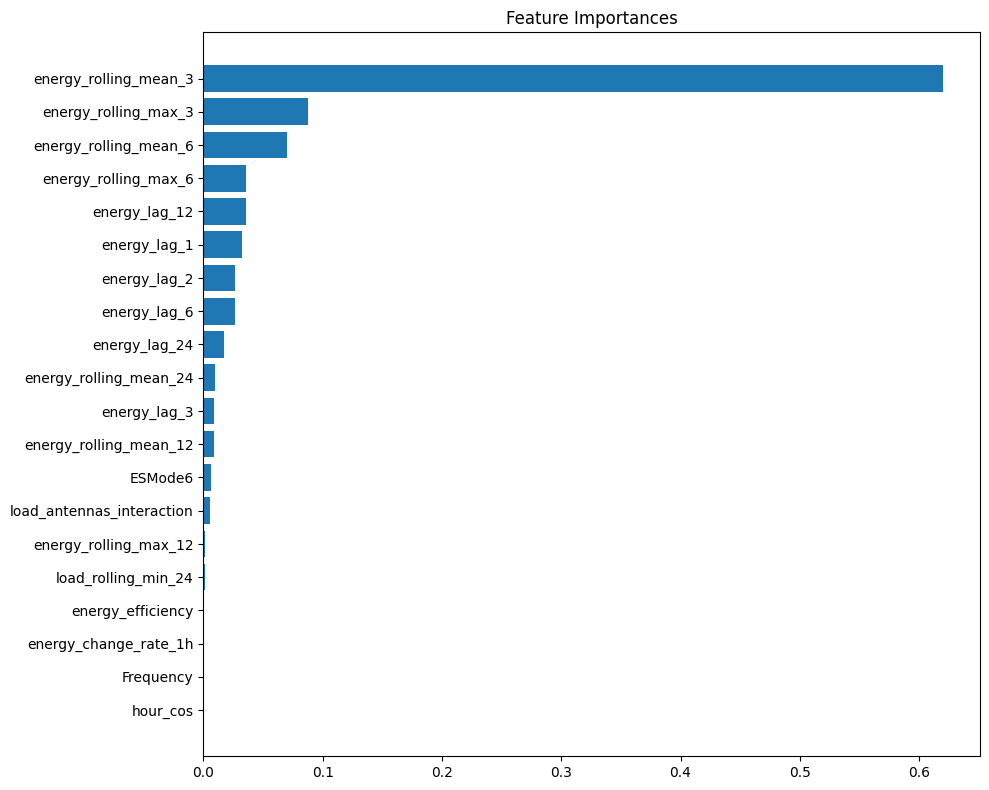

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
import joblib
import os

def validate_model_performance():
    """
    Run a series of tests to validate if the model is truly generalizing
    or if there's data leakage/overfitting.
    """
    # Load the engineered data
    print("Loading engineered data...")
    data = pd.read_csv('engineered_data.csv')

    # Convert Time to datetime
    if 'Time' in data.columns:
        data['Time'] = pd.to_datetime(data['Time'])

    # Sort by time
    data = data.sort_values('Time')

    # Define target and exclude non-feature columns
    target_col = 'Energy'
    exclude_cols = ['Time', 'BS', 'CellName', target_col]

    # Create different feature sets to test
    print("\n1. Testing different feature sets...")

    # All features
    all_features = [col for col in data.columns if col not in exclude_cols]

    # No energy-derived features
    energy_features = [col for col in all_features if 'energy' in col.lower()]
    non_energy_features = [col for col in all_features if col not in energy_features]

    print(f"Total features: {len(all_features)}")
    print(f"Energy-derived features: {len(energy_features)}")
    print(f"Non-energy features: {len(non_energy_features)}")

    feature_sets = {
        'all_features': all_features,
        'no_energy_features': non_energy_features
    }

    # Run tests with different temporal splits
    results = {}

    # Test 1: Simple random forest with different feature sets
    print("\n2. Training models with different feature sets...")

    for name, features in feature_sets.items():
        # Create X and y
        X = data[features]
        y = data[target_col]

        # Split data - 80% train, 20% test
        split_idx = int(len(data) * 0.8)
        X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
        y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

        # Train a simple random forest
        model = RandomForestRegressor(n_estimators=100, random_state=42)
        model.fit(X_train, y_train)

        # Evaluate
        train_preds = model.predict(X_train)
        test_preds = model.predict(X_test)

        train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
        test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))
        train_r2 = r2_score(y_train, train_preds)
        test_r2 = r2_score(y_test, test_preds)

        results[name] = {
            'train_rmse': train_rmse,
            'test_rmse': test_rmse,
            'train_r2': train_r2,
            'test_r2': test_r2
        }

        print(f"{name}: Train R² = {train_r2:.4f}, Test R² = {test_r2:.4f}")

    # Test 2: Forward-chaining cross validation (more realistic for time series)
    print("\n3. Testing with time-series cross-validation...")

    # Create 5 time-based folds
    tscv = TimeSeriesSplit(n_splits=5)

    for name, features in feature_sets.items():
        cv_results = []

        X = data[features]
        y = data[target_col]

        for train_idx, test_idx in tscv.split(X):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            model = RandomForestRegressor(n_estimators=50, random_state=42)
            model.fit(X_train, y_train)

            # Evaluate
            test_preds = model.predict(X_test)
            test_r2 = r2_score(y_test, test_preds)
            cv_results.append(test_r2)

        print(f"{name} time-series CV R²: {np.mean(cv_results):.4f} (std: {np.std(cv_results):.4f})")

    # Test 3: Test on distant future data
    print("\n4. Testing on distant future data...")

    # Get the earliest and latest dates
    earliest_date = data['Time'].min()
    latest_date = data['Time'].max()
    range_days = (latest_date - earliest_date).days

    # Define train and test periods with a significant gap
    # Train on first 60%, test on last 20%
    train_end_date = earliest_date + pd.Timedelta(days=int(range_days * 0.6))
    test_start_date = latest_date - pd.Timedelta(days=int(range_days * 0.2))

    print(f"Train period: {earliest_date} to {train_end_date}")
    print(f"Test period: {test_start_date} to {latest_date}")

    for name, features in feature_sets.items():
        # Create train and test sets
        train_mask = data['Time'] <= train_end_date
        test_mask = data['Time'] >= test_start_date

        X_train = data.loc[train_mask, features]
        y_train = data.loc[train_mask, target_col]
        X_test = data.loc[test_mask, features]
        y_test = data.loc[test_mask, target_col]

        # Train model
        model = RandomForestRegressor(n_estimators=100, random_state=42)
        model.fit(X_train, y_train)

        # Evaluate
        train_preds = model.predict(X_train)
        test_preds = model.predict(X_test)

        train_r2 = r2_score(y_train, train_preds)
        test_r2 = r2_score(y_test, test_preds)

        print(f"{name} distant future R²: Train={train_r2:.4f}, Test={test_r2:.4f}")

    # Test 4: Feature importance
    print("\n5. Top 20 important features:")

    X = data[all_features]
    y = data[target_col]

    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X, y)

    # Get feature importance
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1]

    # Print top 20 features
    top_features = [(all_features[i], importances[i]) for i in indices[:20]]
    for i, (feature, importance) in enumerate(top_features):
        print(f"{i+1}. {feature}: {importance:.4f}")

    # Plot feature importance
    plt.figure(figsize=(10, 8))
    plt.title("Feature Importances")
    plt.barh(range(20), [imp for _, imp in top_features][::-1])
    plt.yticks(range(20), [feat for feat, _ in top_features][::-1])
    plt.tight_layout()
    plt.savefig('feature_importance_validation.png')

    print("\nFeature importance plot saved to 'feature_importance_validation.png'")

    return results

if __name__ == "__main__":
    results = validate_model_performance()
    print("\nValidation complete.")